# TP5 -  Page Rank and Graph Analysis  (28/04/2025)

## 1 Goal

<font size="3">

In this exercise, we develop a web-page ranking algorithm based on the hyperlink structure of the web, where web pages and hyperlinks can be represented as vertices and directed edges, respectively.

We also compare the PageRank algorithm to a random walk.

</font>

## 2 Introduction

<font size="3">
    
The motivation for ranking web-pages is due to the so-called abundance problem: "the number of pages that could reasonably be returned as relevant is far too large for a human user to digest" (Kleinberg,1999). Thus, the goal of a graph-based ranking
method is to identify the most important documents using the hyperlinked structure of the web. In the following we consider a simplified version of the Google's PageRank (Page et al., 1999), which will be the basis of this exercise.
    
The basic premise of graph-based algorithms, such as PageRank, comes from the academic citation analysis. It is based on the observation that the importance of an academic contribution is directly proportional to the number of times it is cited by other authors. In the context of the world wide web, this roughly corresponds to the number of times a given web page is referenced by other pages. PageRank takes this idea even further and computes the importance of a web page not only from the number of incoming links, but also from the importance of web pages where those links originate. This notion is captured by
the following recursive formula that computes the rank $R(u)$ of a web page $u$:
    
\begin{equation}
R(u)=\sum_{v \in B_{u}} \frac{R(v)}{L(v)},
\end{equation}
    
where $B_{u}$ is a set of web pages linking to $u$, and $L(v)$ for a given page $v$ is the
number of links originating from $v$.
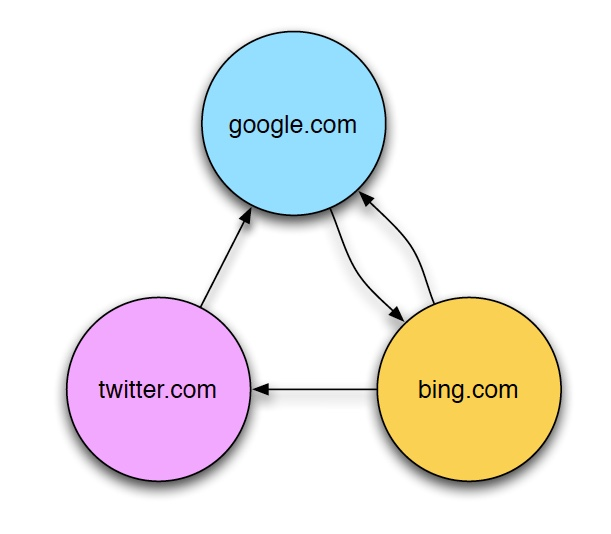



For instance, using a miniature model of the WWW with 3 web pages twitter.com, google.com, bing.com as in the above Figure, we obtain  
    
    
|Web Page    |$B_{u}$             |L(v)        |                       
|------------|--------------------|------------|
|google.com  |twitter.com,bing.com|1           |
|twitter.com |bing.com            |1           |   
|bing.com    |google.com          |2           |
    
    
<br>Starting with $R(google.com) = R(twitter.com) = R(bing.com) = 1/3$, we compute the PageRank formula iteratively until convergence, when $R(google.com) = 0.4$, $R(twitter.com) = 0.2, \hspace{1mm} R(bing.com) = 0.4$.

The above iterative process can be interpreted formally with matrix notations. Given a graph of $N$ web-pages, $R$ denotes an $N$ dimensional column vector, where $R(u)$ is the PageRank value of page $u$. Initially $R(u) = 1/N$ for all web-pages. Let $A$ be the $N \times N$ graph adjacency matrix, where $A(u,v)$ denotes the probability for a random surfer to jump from page($u$) to page($v$). There are two cases: if there is a hyperlink from page($u$) to page($v$), then $A(u,v) = 1/L(u)$; if otherwise, $A(u,v)=0$. Note that $A$ is not necessarily symmetric. In the case of the 3-page example, we have matrix $A$ represented as
    
|   A(u,v)  | google.com | twitter.com | bing.com |
|-----------|------------|-------------|----------|
|google.com | 0          | 0           | 1        |
|twitter.com| 1          | 0           | 0        |  
|bing.com   | 0.5        | 0.5         | 0        |  


Thus, the PageRank is updated as
    
\begin{equation}
R_{k}=A^{T}R_{k-1},
\end{equation}
    
with $k=1,2,3,...$, until convergence. The convergence can be detected by checking the $L_{1}$-norm of $R_{k}-R_{k-1}$. When this norm is sufficiently close to zero, the iteration stops. This iterative procedure coincides with the "Power Method" to find the principal eigenvector $R$ of matrix $A^{T}$, that is, the eigenvector corresponding to the largest eigenvalue.

</font>

## 3. Tasks

### 3.1 Page Rank

<font size="3">

<ol>
    <li>Consider a set of web pages $A, B, C, D, E, F, G$ interconnected by hyperlinks as shown below. Give the above defined adjacency matrix for this graph.
    <img src="./figures/graph.jpg" alt="graph plot" style="width: 300px;" /></li>
    <li>Implement the PageRank iterative algorithm as a function that takes an adjacency matrix as input and outputs a vector of web-page ranks. Find the web-page from the given set $A, B, C, D, E, F, G$ that has the highest rank.
Compare the computed PageRank values with the number of incoming links for each web-page and explain your findings.</li>
    <li>Compute the principal eigenvector of $A^{T}$, where $A$ is the adjacency matrix that you constructed in Task 1. Compare this eigenvector with the PageRank vector you obtained in Task 2, and explain your result.</li>
    <li>For this part you can use any graph package of your choice. The use of <a href="https://networkx.github.io/" target="_blank">networkx</a> is recommended.
<ol>
    <li>Generate a random Graph using the Barabsi-Albert model.</li>
    <li>Compute PageRank eigenvalue.</li>
    <li>Compute the ranking defined as the number of traversal from a random initial node.</li>
    <li>Experiment with different sizes of graphs.</li>
</ol>
     <li>(Optional / Extra credit) Say, the web-page $F$ in Task 1 is someone's homepage. They want $F$ to be ranked as high as possible. Therefore, they create $M$ spam sites (for example, $M=100$) and make all of them link to $F$. Assume no page links to the $M$ spam sites, and there are no links within the spam sites. Re-compute the PageRank values of all $M+7$ web-pages and explain your result.</li>
    <li>(Optional / Extra credit) Rank $A-G$ with the $HITS$ algorithm instead of PageRank. Discuss the relation between these two algorithms.</li>
</ol>
</font>

## 3 Assessment

<font size="3">
    
Please save your notebook as "TP5_NameSurname.ipynb" and upload it to <a href="http://moodle.unige.ch" target="_blank">Moodle</a> in the section <b>Submissions 2025</b> under TP5 before Sunday, May 11, 2025, 23:59.
Later submissions will not be accepted.
    
</font>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Imports
import numpy as np
import pandas as pd

1. Consider a set of web pages $A, B, C, D, E, F, G$ interconnected by hyperlinks as shown below. Give the above defined adjacency matrix for this graph.

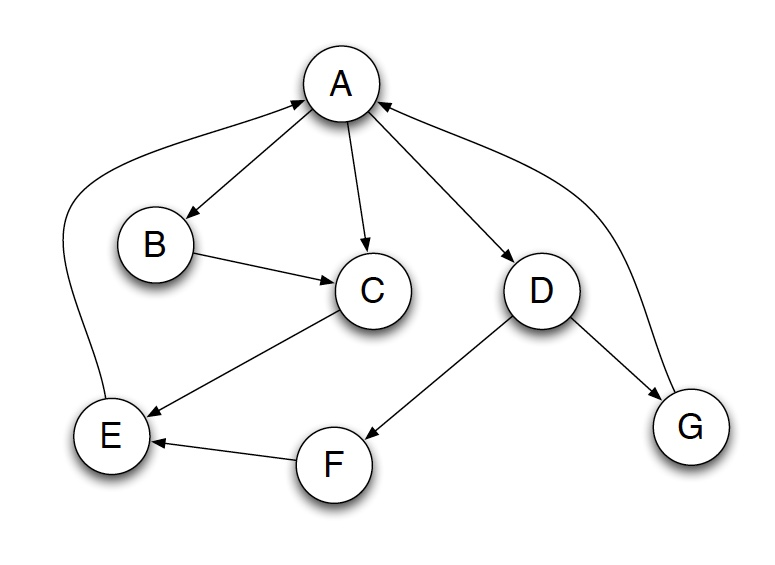

In [ ]:
# create an adjacency matrix A of size 7x7
A = np.zeros((7, 7))
# A

# number of links originating from each page
L = {
    "A":3, "B":1, "C":1, "D":2,
    "E":1, "F":1, "G":1
    }

# node/page A
val = 1 / L["A"]
A[0, 1] = val
A[0, 2] = val
A[0, 3] = val

# node/page B
val = 1 / L["B"]
A[1, 2] = val

# node/page C
val = 1 / L["C"]
A[2, 4] = val

# node/page D
val = 1 / L["D"]
A[3, 5] = val
A[3, 6] = val

# node/page E
val = 1 / L["E"]
A[4, 0] = val

# node/page F
val = 1 / L["F"]
A[5, 4] = val

# node/page G
val = 1 / L["G"]
A[6, 0] = val

# A


In [ ]:
# A.shape[0]

2. Implement the PageRank iterative algorithm as a function that takes an adjacency matrix as input and outputs a vector of web-page ranks. Find the web-page from the given set $A, B, C, D, E, F, G$ that has the highest rank.
Compare the computed PageRank values with the number of incoming links for each web-page and explain your findings.

In [ ]:
# PageRank iterative algorithm as a function
def page_rank(A, max_iter=300, epsilon=1e-6):
  # print(A.shape)
  N = A.shape[0]

  # rank vector R initialized to 1/N
  R = np.ones(N)/N
  # print(R)
  for i in range(max_iter):
    # update ranks
    # print("Iteration: ", i, "R: ", R)
    R_current = A.T@R

    # compute l1 norm to check convergence
    l1_norm = np.linalg.norm(R_current - R, ord=1)
    if l1_norm < epsilon:
            # print(f"converged after {i+1} iterations")
            # print("Finish ", i)
            break

    R = R_current

  return R

In [ ]:
page_rank(A)

array([0.28571409, 0.0952382 , 0.19047633, 0.0952382 , 0.23809504,
       0.04761907, 0.04761907])

In [ ]:
# table for nicer view
df = pd.DataFrame({'Page': L.keys(), 'Rank': page_rank(A)})
df = df.sort_values(by='Rank', ascending=False).reset_index(drop=True)
df

,Page,Rank
0,A,0.285714
1,E,0.238095
2,C,0.190476
3,B,0.095238
4,D,0.095238
5,F,0.047619
6,G,0.047619


## Comments
The ranking generated by the PageRank algorithm reflects the structure of the graph quite well:

- **Node A** is the highest-ranked node. It makes sense because it has multiple outgoing links and is referenced by two other nodes (B and D). This *centrality* results in a strong PageRank.

- **Node E** follows, with a relatively high score. It receives incoming links from both C and F, making it well-referenced and thus significant in the network.

- **Node C** is next, connected to both A and B (incoming) and linking to E (outgoing). Its intermediate position in the graph and multiple links contribute to its moderate PageRank.

- **Nodes B and D** share the same PageRank score. Both have one incoming and one outgoing link, giving them a mid-level importance in the network.

- **Nodes F and G** have the lowest PageRank values. Each of them has only one incoming and one outgoing link, resulting in minimal influence or visibility within the graph structure.



I was also wondering why nodes B and D, and nodes F and G, each have one incoming and one outgoing link, yet their PageRank scores are different. At first glance, i would've expected them to have similar scores. However, the difference likely comes from the fact that B and D are pointed to by a highly ranked node namely A. Being referenced by a popular or central node (or individual in general) boosts your own score/popularity. On the other hand, simply pointing to a popular node, as F and G do, doesn't necessarily increase their own PageRank. So, the higher scores of B and D compared to F and G can be explained by the importance of the source of the incoming links rather than just the number of links themselves.


3. Compute the principal eigenvector of $A^{T}$, where $A$ is the adjacency matrix that you constructed in Task 1. Compare this eigenvector with the PageRank vector you obtained in Task 2, and explain your result.

In [ ]:
 # Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A.T)
eigenvalues

# # Find the index of the largest eigenvalue
principal_index = np.argmax(np.abs(eigenvalues))

# # Get the principal eigenvector
principal_eigenvector = eigenvectors[:, principal_index]

# # # Optionally, normalize so it sums to 1 (common for PageRank and probability vectors)
# # principal_eigenvector_normalized = principal_eigenvector / principal_eigenvector.sum()

print("Principal eigenvector:", np.real(principal_eigenvector))
# print("Normalized principal eigenvector:", principal_eigenvector_normalized)


Principal eigenvector: [-0.64326752 -0.21442251 -0.42884501 -0.21442251 -0.53605627 -0.10721125
 -0.10721125]


## Comments
The principal eigenvector is very related to the ranking that we have earlier it is actually a scaled version of those rankings, this makes sense as the principal eigenvector of $A^{T}$ gives the eigenvector centrality (measures a node's importance/ranking)


  4. For this part you can use any graph package of your choice. The use of <a href="https://networkx.github.io/" target="_blank">networkx</a> is recommended.
  <ul>
    <li>Generate a random Graph using the Barabsi-Albert model.</li>
    <li>Compute PageRank eigenvalue.</li>
    <li>Compute the ranking defined as the number of traversal from a random initial node.</li>
    <li>Experiment with different sizes of graphs.</li>
  </ul>



--- Graph with 10 nodes ---
Top 5 nodes by PageRank: [(3, 0.17725927327393678), (0, 0.1548249941918837), (4, 0.14912778729671208), (5, 0.12163039163323192), (2, 0.0917842847720825)]
Top 5 nodes by Random Walk visits: [(3, 1875), (0, 1639), (4, 1542), (5, 1184), (2, 968)]


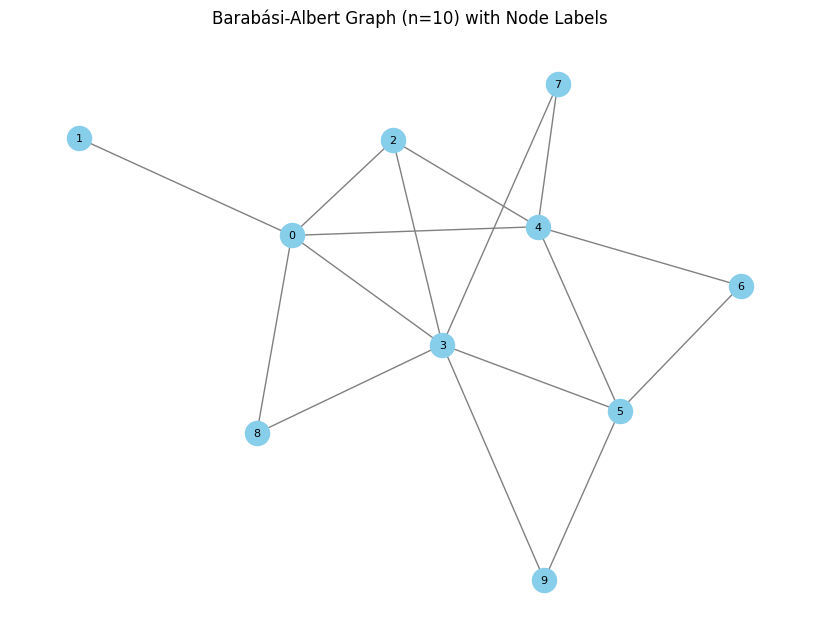


--- Graph with 50 nodes ---
Top 5 nodes by PageRank: [(3, 0.08908090773333177), (0, 0.07503907985841754), (2, 0.066962761502925), (1, 0.03835600674957141), (10, 0.03534140292271944)]
Top 5 nodes by Random Walk visits: [(3, 1067), (0, 792), (2, 692), (5, 395), (1, 368)]


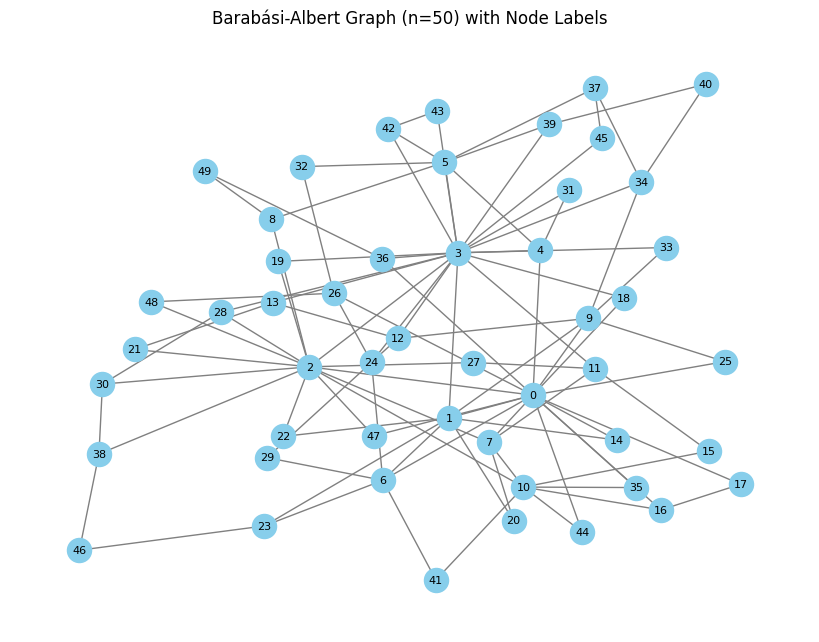


--- Graph with 100 nodes ---
Top 5 nodes by PageRank: [(4, 0.06520029269204686), (2, 0.036350767517044344), (6, 0.0290142903799614), (10, 0.027524395279498216), (5, 0.02693606928039905)]
Top 5 nodes by Random Walk visits: [(4, 716), (2, 462), (6, 335), (10, 331), (5, 311)]


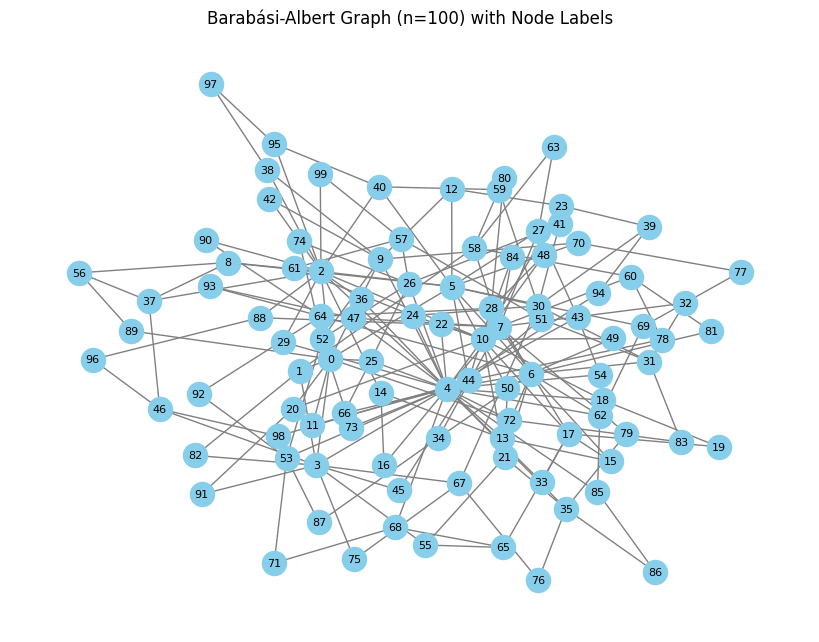

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random

def generate_ba_graph(n, m):
    G = nx.barabasi_albert_graph(n=n, m=m)
    return G

def compute_pagerank(graph):
    return nx.pagerank(graph)

def random_walk_ranking(graph, steps=10000, start_node=None):
    if start_node is None:
        start_node = random.choice(list(graph.nodes()))

    current_node = start_node
    visits = Counter()

    for _ in range(steps):
        visits[current_node] += 1
        neighbors = list(graph.neighbors(current_node))
        if not neighbors:
            break
        current_node = random.choice(neighbors)

    return dict(visits)

def experiment(graph_sizes, m=2):
    for n in graph_sizes:
        print(f"\n--- Graph with {n} nodes ---")
        G = generate_ba_graph(n, m)

        # Compute PageRank
        pr = compute_pagerank(G)
        top_pagerank = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:5]
        print("Top 5 nodes by PageRank:", top_pagerank)

        # Compute Random Walk ranking
        rw_rank = random_walk_ranking(G, steps=10000)
        top_rw = sorted(rw_rank.items(), key=lambda x: x[1], reverse=True)[:5]
        print("Top 5 nodes by Random Walk visits:", top_rw)

        # Visualize graph with labeled nodes
        plt.figure(figsize=(8, 6))
        pos = nx.spring_layout(G)
        nx.draw(G, pos, node_size=300, with_labels=True, font_size=8, node_color='skyblue', edge_color='gray')
        plt.title(f"Barabási-Albert Graph (n={n}) with Node Labels")
        plt.show()

# Run the experiment with different graph sizes
experiment(graph_sizes=[10, 50, 100])


## Comments
An obvious correlation appears between the number of visits during the random walk and the PageRank: the more a page is visited, the more popular it likely is, which makes sense.
I also noticed that as the graph gets larger (meaning we have more pages) the average number of visits per page tends to decrease. This behavior can be explained by the fact that the graph is based on the Barabási–Albert model, which generates scale-free networks where a few nodes (hubs) have many connections, while most have very few. As the graph size grows, the influence of these hubs becomes more pronounced, spreading the visits more thinly across the many low-degree nodes.

5. (Optional / Extra credit) Say, the web-page $F$ in Task 1 is someone's homepage. They want $F$ to be ranked as high as possible. Therefore, they create $M$ spam sites (for example, $M=100$) and make all of them link to $F$. Assume no page links to the $M$ spam sites, and there are no links within the spam sites. Re-compute the PageRank values of all $M+7$ web-pages and explain your result.

In [ ]:
A[:, 5]

array([0. , 0. , 0. , 0.5, 0. , 0. , 0. ])

In [ ]:
# Parameters
M = 100
A = np.zeros((M + 7, M + 7))

# number of links originating from each page
L = {
    "A":3, "B":1, "C":1, "D":2,
    "E":1, "F":1, "G":1
    }

# node/page A
val = 1 / L["A"]
A[0, 1] = val
A[0, 2] = val
A[0, 3] = val

# node/page B
val = 1 / L["B"]
A[1, 2] = val

# node/page C
val = 1 / L["C"]
A[2, 4] = val

# node/page D
val = 1 / L["D"]
A[3, 5] = val
A[3, 6] = val

# node/page E
val = 1 / L["E"]
A[4, 0] = val

# node/page F
val = 1 / L["F"]
A[5, 4] = val

# node/page G
val = 1 / L["G"]
A[6, 0] = val

# add M spam pages
for i in range(7, M + 7):
    A[i, 5] = 1.0  # each spam page links only to F


# Compute PageRank
# ranks = page_rank(A)

# print(A)


page_names = list("ABCDEFG") + [f"Spam{i}" for i in range(1, M+1)]
df = pd.DataFrame({'Page': page_names, 'Rank': page_rank(A)})

df_main = df.iloc[:7]
df_main

,Page,Rank
0,A,0.285714
1,B,0.095238
2,C,0.190476
3,D,0.095238
4,E,0.238095
5,F,0.047619
6,G,0.047619


## Explanation

This part was a bit challenging and stimulated a lot of reflection as i implemented everything correctly, but still couldn’t manage to make page F as popular as wanted by the method prposed. Adding 100 spam pages all pointing to F didn’t actually boost its. In the second iteration, I did see a noticeable increase in F’s PageRank — which makes sense because all the spam pages were pointing to it. But after that, the score dropped again (See logs). I realized it’s because there’s no way to go back to those spam pages — they don’t have any incoming links and don’t link to each other either. So once their initial influence is used, it's like they disappear and so F return to it's initial popularity (without spams pointing to it). Based on this, I’d say that just adding spam pages isn’t a good way to keep F ranked high. There needs to be some way to revisit those pages (spams) so they point again to F.


I tried proposing a solution and added now links from F to the spams so they can be revisited.


In [ ]:
# Parameters
M = 100
A = np.zeros((M + 7, M + 7))

# number of links originating from each page
L = {
    "A":3, "B":1, "C":1, "D":2,
    "E":1, "F":1, "G":1
    }

# node/page A
val = 1 / L["A"]
A[0, 1] = val
A[0, 2] = val
A[0, 3] = val

# node/page B
val = 1 / L["B"]
A[1, 2] = val

# node/page C
val = 1 / L["C"]
A[2, 4] = val

# node/page D
val = 1 / L["D"]
A[3, 5] = val
A[3, 6] = val

# node/page E
val = 1 / L["E"]
A[4, 0] = val

# node/page F
val = 1 / L["F"]
A[5, 4] = val

# node/page G
val = 1 / L["G"]
A[6, 0] = val

# add M spam pages
for i in range(7, M + 7):
    A[i, 5] = 1.0  # each spam page links only to F
    A[5, i] = 1/(M+1)

A[5, 4] = 1/(M+1)

# Compute PageRank
# ranks = page_rank(A)

# print(A)


page_names = list("ABCDEFG") + [f"Spam{i}" for i in range(1, M+1)]
df = pd.DataFrame({'Page': page_names, 'Rank': page_rank(A)})

df_main = df.iloc[:7]
df_main

,Page,Rank
0,A,0.026036
1,B,0.009423
2,C,0.018098
3,D,0.009423
4,E,0.023920
5,F,0.326834
6,G,0.004338


At least now, F is highly ranked :>

6. (Optional / Extra credit) Rank $A-G$ with the $HITS$ algorithm instead of PageRank. Discuss the relation between these two algorithms.

In [ ]:
import numpy as np

def hits(A, max_iter=300, epsilon=1e-6):
    N = A.shape[0]

    # Initialize authority and hub scores to 1
    authority = np.ones(N)
    hub = np.ones(N)

    for i in range(max_iter):
        # Update authority scores: a = A^T * h
        new_authority = A.T @ hub
        # Update hub scores: h = A * a
        new_hub = A @ new_authority

        # Normalize
        new_authority /= np.linalg.norm(new_authority, ord=2)
        new_hub /= np.linalg.norm(new_hub, ord=2)

        # Check convergence (L2 norm for both)
        if (np.linalg.norm(new_authority - authority, ord=2) < epsilon and
            np.linalg.norm(new_hub - hub, ord=2) < epsilon):
            break

        authority = new_authority
        hub = new_hub

    return authority, hub


In [ ]:
# create an adjacency matrix A of size 7x7
A = np.zeros((7, 7))
# A

# number of links originating from each page
L = {
    "A":3, "B":1, "C":1, "D":2,
    "E":1, "F":1, "G":1
    }

# node/page A
val = 1 / L["A"]
A[0, 1] = val
A[0, 2] = val
A[0, 3] = val

# node/page B
val = 1 / L["B"]
A[1, 2] = val

# node/page C
val = 1 / L["C"]
A[2, 4] = val

# node/page D
val = 1 / L["D"]
A[3, 5] = val
A[3, 6] = val

# node/page E
val = 1 / L["E"]
A[4, 0] = val

# node/page F
val = 1 / L["F"]
A[5, 4] = val

# node/page G
val = 1 / L["G"]
A[6, 0] = val

# A


In [ ]:
df = pd.DataFrame({'Page': page_names, 'Rank': hits(A)})

df_main = df.iloc[:7]
df_main

In [ ]:
authority, hub = hits(A)

# Create DataFrame
df = pd.DataFrame([authority, hub], index=['authority', 'hub'],
                  columns=['A', 'B', 'C', 'D', 'E', 'F', 'G'])

df.transpose()

,authority,hub
A,7.071068e-01,5.836426e-07
B,2.417527e-07,1.409038e-06
C,1.992680e-06,5.000000e-01
D,2.417527e-07,7.105427e-15
E,7.071068e-01,5.000000e-01
F,1.004859e-14,5.000000e-01
G,1.004859e-14,5.000000e-01


PageRank and HITS are closely related in that both analyze the link structure of a graph to rank nodes, but they differ in how they define and compute importance. Both use iterative methods and eigenvector calculations, but while PageRank produces a single score reflecting a node’s overall importance, HITS computes two scores: authority and hub. Mathematically, PageRank simulates a random walk and uses the entire graph with a transition matrix. HITS, by contrast, uses the adjacency matrix and alternates updates between authority and hub vectors, to capture different roles nodes play: some as sources of information (hubs) and others as destinations (authorities). In PageRank, a node is important if linked to by other important nodes; in HITS, a good authority is pointed to by good hubs, and vice versa.

Just maybe to add some comments about the results of the HITS algorithm and how they relate to those of the PageRank algorithm. As you can see, A is an authority (a node with valuable content) and the same goes for E. The most important hubs are C, F, and G because they point to authorities, namely A and E. This globally reflects the  previous results of the PageRank algorithm and, by the way, the close connection between the two algorithms.
